In [1]:
# Constants for color print
class bcolors:
    HEADER = '\033[95m'
    OKBLUE = '\033[94m'
    OKCYAN = '\033[96m'
    OKGREEN = '\033[92m'
    WARNING = '\033[93m'
    FAIL = '\033[91m'
    ENDC = '\033[0m'
    BOLD = '\033[1m'
    UNDERLINE = '\033[4m'

def print_matrix(matrix):

    rows = matrix.shape[0]
    columns = matrix.shape[1]

    number_size = max([len(f"{matrix[r, c]:.3f}") for r in range(rows) for c in range(columns)])

    for r in range(rows):
        for c in range(columns):
            element = ""
            non_zero = False

            if matrix[r, c] != 0:
                element = f"{matrix[r, c]:.3f}"
                non_zero = True
                # print(bcolors.FAIL + f"{matrix[r, c]:.2f}" + bcolors.ENDC, end = " "*4)

            elif matrix[r, c] == 0:
                element = "0"
                # print("0", end = " "*4)

            spacing_left = ((number_size - len(element)) // 2)
            spacing_rigth = spacing_left + (number_size - len(element)) % 2

            element = " "*spacing_left + element + " "*spacing_rigth
            print(element, end = " "*4)
            


        print("\n", end = "") 

In [2]:
import numpy as np
from two_level_decomposition import *
dimensions = 8

# Generate random Hermitian matrix
H = 2 * np.random.rand(dimensions, dimensions) - np.ones((dimensions, dimensions))
H = H + 2j * (2 * np.random.rand(dimensions, dimensions) - np.ones((dimensions, dimensions)))
H = H + H.conj().T  # Hermitian matrix

_, U = np.linalg.eigh(H)  # U is unitary (columns are eigenvectors)

matrices, matrices_json = two_level_decomposition(U, dimensions)

A = np.eye(dimensions, dtype=complex)
for i in range(1, len(matrices)):   # skip index 0 (None placeholder)
    if matrices[i] is not None:
        A = matrices[i] @ A
        

# Check if A† = U1† * U2† * ... is equal to U
print(np.all(np.abs(A.conj().T - U) < 1e-10))

True


In [3]:
print_matrix(matrices[5])

0.98-0.00j          0              0              0              0         0.04+0.17j          0              0         
     0         1.00+0.00j          0              0              0              0              0              0         
     0              0         1.00+0.00j          0              0              0              0              0         
     0              0              0         1.00+0.00j          0              0              0              0         
     0              0              0              0         1.00+0.00j          0              0              0         
0.04-0.17j          0              0              0              0         -0.98-0.00j         0              0         
     0              0              0              0              0              0         1.00+0.00j          0         
     0              0              0              0              0              0              0         1.00+0.00j     


In [4]:
matrices_json[4]

{'states': [0, 5],
 'matrix': array([[ 0.98389235-8.37330403e-21j,  0.0429613 +1.73522806e-01j],
        [ 0.0429613 -1.73522806e-01j, -0.98389235-8.37330403e-21j]])}

In [5]:
for k, matrix_json in enumerate(matrices_json):
    print(f"U{k + 1}:")
    print(f"States in which the matrix act: {matrix_json['states']}")
    print(f"2 by 2 non-trivial block:")
    print_matrix( matrix_json["matrix"])
    print(f"Check if non-trivial block is unitary: {is_unitary(matrix_json["matrix"])}")
    print()

U1:
States in which the matrix act: [0, 1]
2 by 2 non-trivial block:
-0.69+0.00j    0.19-0.69j     
0.19+0.69j     0.69-0.00j     
Check if non-trivial block is unitary: True

U2:
States in which the matrix act: [0, 2]
2 by 2 non-trivial block:
0.90-0.00j     0.23-0.37j     
0.23+0.37j     -0.90-0.00j    
Check if non-trivial block is unitary: True

U3:
States in which the matrix act: [0, 3]
2 by 2 non-trivial block:
0.90+0.00j     -0.41-0.11j    
-0.41+0.11j    -0.90+0.00j    
Check if non-trivial block is unitary: True

U4:
States in which the matrix act: [0, 4]
2 by 2 non-trivial block:
0.93+0.00j     -0.00-0.36j    
-0.00+0.36j    -0.93+0.00j    
Check if non-trivial block is unitary: True

U5:
States in which the matrix act: [0, 5]
2 by 2 non-trivial block:
0.98-0.00j     0.04+0.17j     
0.04-0.17j     -0.98-0.00j    
Check if non-trivial block is unitary: True

U6:
States in which the matrix act: [0, 6]
2 by 2 non-trivial block:
0.89+0.00j     -0.34-0.30j    
-0.34+0.30j    -0.89

In [6]:
print_matrix(U)

-0.45+0.00j    0.29+0.00j     -0.36+0.00j    -0.36+0.00j    -0.42+0.00j    0.35+0.00j     -0.06+0.00j    -0.38+0.00j    
0.13+0.45j     -0.35+0.17j    -0.36-0.10j    -0.25-0.12j    -0.12+0.03j    -0.01+0.18j    0.53+0.18j     0.21-0.10j     
0.17+0.27j     0.34+0.05j     0.47-0.33j     -0.03+0.40j    -0.01-0.16j    0.16+0.28j     0.22+0.21j     -0.24+0.07j    
-0.33+0.09j    -0.02-0.27j    0.04-0.07j     0.15+0.25j     0.02-0.11j     -0.31-0.28j    0.34-0.23j     -0.16-0.58j    
-0.00+0.31j    0.33-0.36j     -0.07+0.15j    0.18-0.09j     -0.07+0.08j    0.13+0.48j     -0.25-0.12j    0.39-0.33j     
0.04-0.15j     0.02+0.02j     -0.17-0.45j    -0.21+0.21j    0.21+0.68j     -0.23+0.16j    -0.20+0.07j    -0.07-0.19j    
-0.34+0.29j    -0.20+0.20j    0.20-0.30j     -0.09-0.05j    0.35+0.04j     0.43-0.12j     -0.12-0.46j    0.18+0.05j     
-0.14+0.10j    0.11+0.50j     0.03+0.05j     0.63-0.14j     -0.13+0.34j    0.17-0.13j     0.06+0.26j     -0.08-0.18j    


In [13]:
dict_circuit_abstraction2 = convert_1to2(U, "abstraction2.json")

In [14]:
from convert_2to3 import *

dict_circuit_abstraction3 = convert_2to3(dict_circuit_abstraction2, "abstraction3.json")

In [15]:
from generate_circuits import *

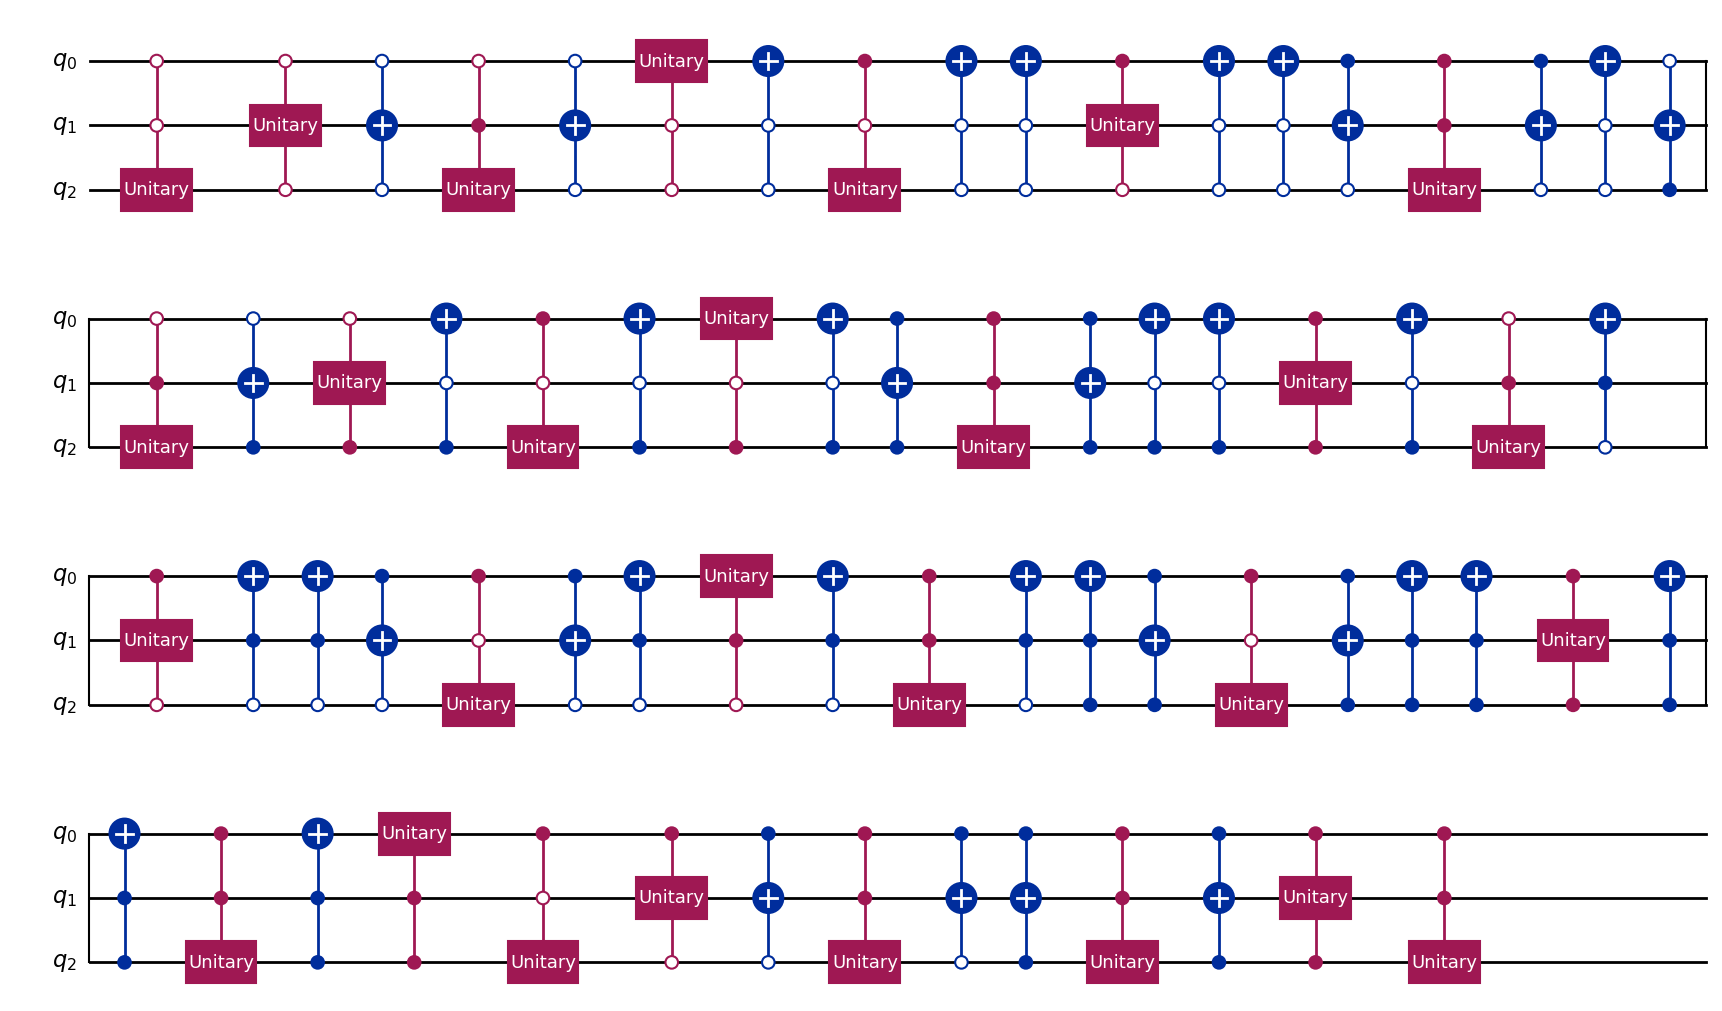

In [16]:
qc = json_to_circuit(dict_circuit_abstraction2)
qc.draw("mpl")

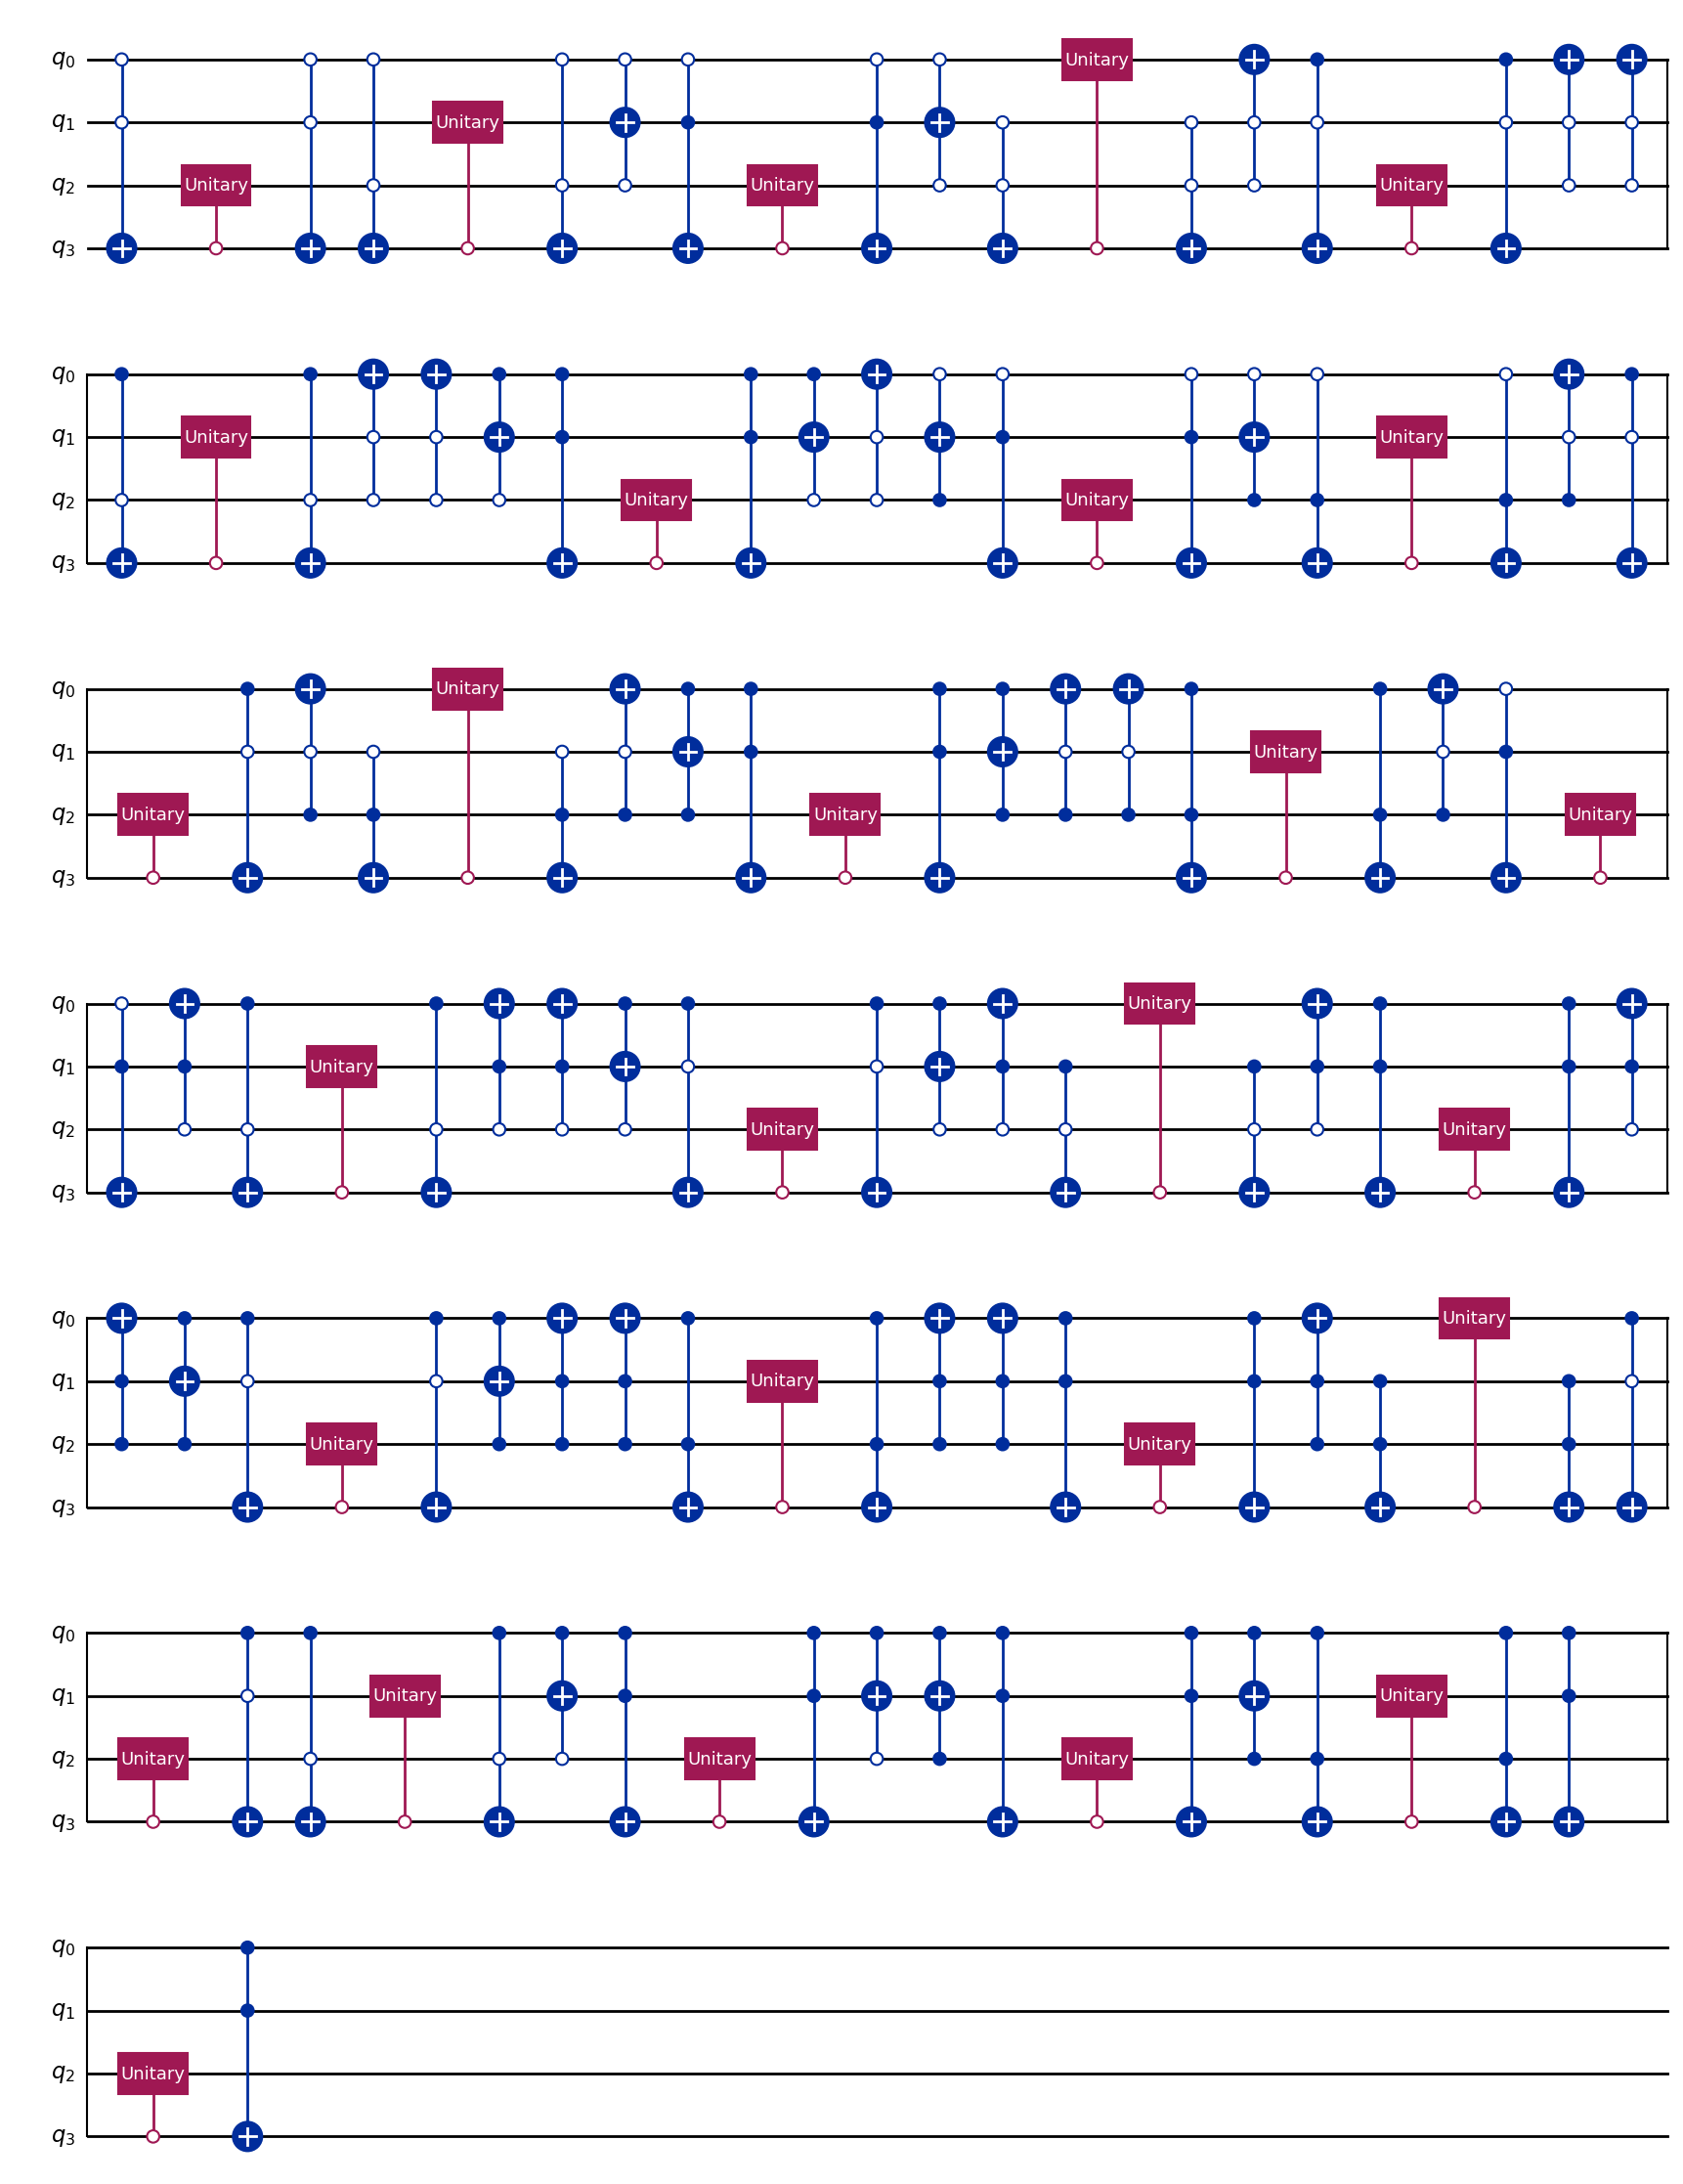

In [17]:
qc = json_to_circuit_abstraction3(dict_circuit_abstraction3)
qc.draw("mpl")